<a href="https://colab.research.google.com/github/Jormao2025/Data_Science_1/blob/main/Proyecto_Final_Data_Science_III_An%C3%A1lisis_Sentimiento_en_Tweets_sobre_Vacunas_contra_COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de Sentimiento en Tweets sobre Vacunas contra COVID-19

## 1- Introducción
La pandemia de COVID-19 generó un impacto significativo a nivel global, no solo en términos sanitarios sino también en la forma en que las personas intercambian información y opiniones a través de plataformas digitales. En este contexto, las redes sociales se convirtieron en uno de los principales espacios donde los usuarios expresaron percepciones, preocupaciones y opiniones respecto al desarrollo y distribución de las vacunas contra el virus.

Twitter, en particular, representa una fuente valiosa de información para el análisis de la opinión pública, ya que permite observar reacciones inmediatas frente a eventos de relevancia social. El análisis de estas publicaciones puede contribuir a comprender tendencias de percepción social, identificar preocupaciones comunes y evaluar el impacto de las campañas de comunicación relacionadas con la salud pública.

El Procesamiento de Lenguaje Natural (NLP) y las técnicas de Machine Learning permiten analizar grandes volúmenes de texto provenientes de redes sociales de manera automatizada. Una de las aplicaciones más relevantes dentro de este campo es el análisis de sentimiento, que permite identificar si un texto expresa una opinión positiva, negativa o neutral.

En este proyecto se utilizarán técnicas de procesamiento de lenguaje natural y aprendizaje automático para analizar tweets relacionados con las vacunas contra la COVID-19 y clasificar automáticamente el sentimiento presente en dichos mensajes.

## 2- Problema de negocio

Las redes sociales generan diariamente grandes volúmenes de información que reflejan la percepción y opinión de los usuarios frente a diferentes acontecimientos. Analizar manualmente este tipo de contenido resulta complejo debido a la cantidad de datos disponibles y a la velocidad con la que se producen nuevas publicaciones.

En el contexto de las vacunas contra la COVID-19, comprender la opinión de los usuarios puede aportar información relevante sobre la aceptación social de las campañas de vacunación y las percepciones de la población frente a distintos laboratorios y desarrollos farmacéuticos.

El desafío consiste en procesar y analizar automáticamente miles de publicaciones textuales para identificar el sentimiento asociado a cada mensaje, utilizando herramientas de análisis de texto y modelos de aprendizaje automático capaces de clasificar la polaridad de los tweets.

## 3- Objetivo general

Desarrollar un modelo de clasificación de sentimientos aplicado a tweets relacionados con las vacunas contra la COVID-19, utilizando técnicas de procesamiento de lenguaje natural y aprendizaje supervisado con el fin de identificar automáticamente la polaridad de las opiniones expresadas en las publicaciones.

## 4- Objetivos específicos

- Analizar la estructura y características del conjunto de datos utilizado en el estudio.

- Aplicar técnicas de preprocesamiento de texto para limpiar y normalizar el contenido de los tweets.

- Explorar patrones presentes en el texto mediante análisis de frecuencia de palabras, n-gramas y visualizaciones.

- Transformar los textos en representaciones numéricas mediante técnicas de vectorización como TF-IDF o Bag of Words.

- Entrenar un modelo de aprendizaje supervisado para clasificar los tweets según su sentimiento.

- Evaluar el desempeño del modelo utilizando métricas de clasificación y analizar los resultados obtenidos.

## 4- Origen de los datos
Origen de los datos

El conjunto de datos utilizado en este proyecto proviene del repositorio público Kaggle, específicamente del dataset denominado COVID-19 Vaccine Tweets with Sentiment Annotation https://www.kaggle.com/datasets/datasciencetool/covid19-vaccine-tweets-with-sentiment-annotation?resource=download.
Este dataset contiene una recopilación de tweets relacionados con diferentes vacunas contra la COVID-19, los cuales fueron anotados manualmente con información de sentimiento.

Los identificadores de los tweets fueron obtenidos a partir de un conjunto de datos desarrollado por Gabriel Preda, a partir del cual se recuperó el texto completo de cada publicación. El dataset incluye tweets vinculados a diversas vacunas desarrolladas durante la pandemia, entre ellas Pfizer/BioNTech, Moderna, Oxford/AstraZeneca, Sinopharm, Sinovac, Covaxin y Sputnik V.

Cada tweet posee una etiqueta de sentimiento que indica la polaridad del mensaje, codificada de la siguiente manera:

1 → sentimiento negativo

2 → sentimiento neutral

3 → sentimiento positivo

Esta información permite utilizar el conjunto de datos para tareas de clasificación supervisada, entrenando modelos capaces de identificar automáticamente el sentimiento de nuevas publicaciones en redes sociales.

## 5- Librerías utilizadas
Para el desarrollo del proyecto se utilizaron diversas librerías del ecosistema Python orientadas al análisis de datos, procesamiento de texto y aprendizaje automático.

Las principales herramientas utilizadas incluyen:

- Pandas y NumPy para manipulación y análisis de datos.

- Matplotlib y Seaborn para visualización de información.

- NLTK para tareas de procesamiento de lenguaje natural como tokenización, eliminación de stopwords y lematización.

- Scikit-learn para la implementación de técnicas de vectorización de texto y modelos de machine learning.

- WordCloud para la generación de visualizaciones de frecuencia de palabras.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install nltk
!pip install wordcloud

## 6- Carga y preparación del dataset

In [45]:
import requests

url = "https://github.com/Jormao2025/Data_Science_1/raw/refs/heads/main/covid-19_vaccine_tweets_with_sentiment1.csv"

response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

df = pd.read_csv(url, sep=';', encoding='latin1')

df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

temp = df['tweet_id,label,tweet_text'].str.split(',', n=2, expand=True)

df['tweet_id'] = temp[0]
df['label'] = temp[1]
df['tweet_text'] = temp[2]

df = df[['tweet_id','label','tweet_text']].copy()

df['label'] = pd.to_numeric(df['label'], errors='coerce')

df.dropna(inplace=True)

df = df[['tweet_text','label']].copy()

df.head()



tweet_id,label,tweet_text;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
"1360342002961940483,1,""4,000 a day dying from the so called Covid-19 “vaccine” @DailyBeast reports. #vaccine #PfizerVaccine #Moderna  ";;;;;" """"https://t.co/p1nQWWZ


,tweet_text,label
0,"""4,000 a day dying from the so called Covid-19...",1
1,Pranam message for today manifested in Dhyan b...,2
2,"""Hyderabad-based ?@BharatBiotech? has sought f...",2
3,"""Confirmation that Chinese #vaccines """"""""""""""""d...",1
4,"""Lab studies suggest #Pfizer, #Moderna vaccine...",3


## 7- Análisis exploratorio de datos
En esta etapa se analiza la estructura del dataset, la distribución de las etiquetas de sentimiento y algunas características básicas del texto. Este análisis permite identificar posibles desbalances entre las clases y comprender mejor el contenido de los tweets.

### Distribución de sentimientos

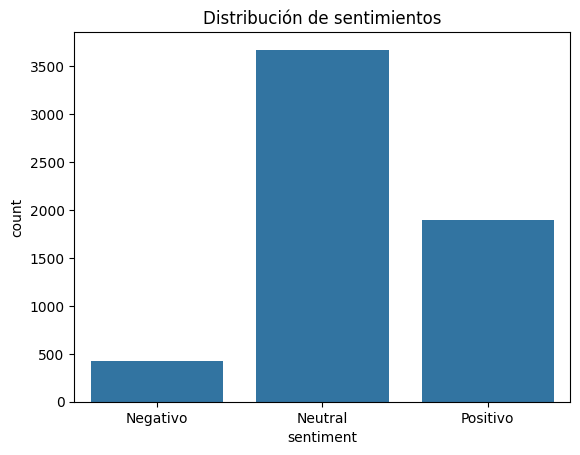

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

label_map = {1:'Negativo',2:'Neutral',3:'Positivo'}
df['sentiment'] = df['label'].map(label_map)

sns.countplot(x='sentiment', data=df)
plt.title("Distribución de sentimientos")
plt.show()

### Longitud de tweets

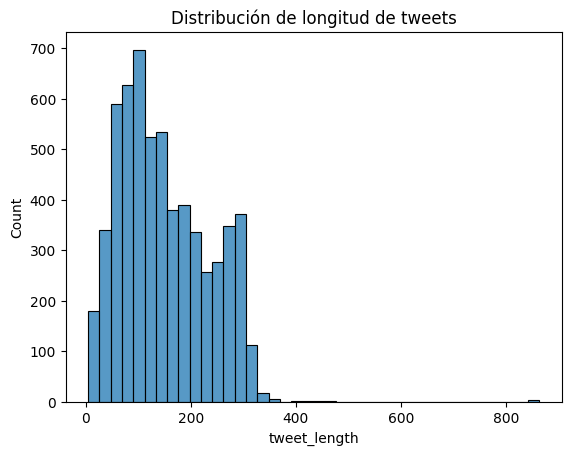

In [47]:
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)

sns.histplot(df['tweet_length'], bins=40)
plt.title("Distribución de longitud de tweets")
plt.show()